# **Проект**

# Тема 3: Для каких типов рядов какая трансформация ряда полезнее?

Берём датасет [M4 Monthly](https://https://zenodo.org/records/4656480) с сайта [forecastingdata.org](https://forecastingdata.org)

In [1]:
!unzip m4_monthly_dataset.zip

Archive:  m4_monthly_dataset.zip
  inflating: m4_monthly_dataset.tsf  


In [2]:
!pip install -q tslearn tsfeatures catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import datetime
from tslearn.clustering import silhouette_score, TimeSeriesKMeans
from tqdm import tqdm

from data_loader import convert_tsf_to_dataframe

## Загружаем данные

In [5]:
df_full, _, _, _, _ = convert_tsf_to_dataframe('m4_monthly_dataset.tsf')

Отфильтруем совсем маленькие ряды

In [6]:
df_full = df_full[df_full.series_value.apply(len).ge(240)].reset_index(drop=True)
df_full.shape

(22564, 3)

## Сэмплируем 100 рядов из датасета

In [7]:
rng = np.random.default_rng(42)

ids = rng.choice(range(df_full.shape[0]), size=100, replace=False)

df_sample = df_full.iloc[ids]
df_sample.head()

,series_name,start_timestamp,series_value
9856,T21466,1978-02-01 12:00:00,"[990.6819591, 959.832234, 952.0460948, 947.402..."
21199,T41375,1991-01-31 12:00:00,"[1630.0, 1600.0, 1640.0, 1690.0, 1680.0, 1600...."
15100,T28515,1996-01-01 12:00:00,"[5743.0, 5754.0, 5801.0, 5842.0, 5848.0, 5831...."
10509,T22231,1990-01-01 12:00:00,"[4023.2, 4021.5, 4026.5, 4012.2, 4057.6, 4113...."
10133,T21851,1990-01-01 12:00:00,"[2540.0, 2610.0, 2630.0, 2620.0, 2610.0, 2720...."


Сразу переведём ряды в Long-формат

In [8]:
df_long = pd.DataFrame()

for id in ids:
    ts = df_sample.loc[id, :]

    values = ts['series_value'][:240] # берём 240 месяцев
    dates =  pd.to_datetime(pd.Series([ts['start_timestamp'] + pd.DateOffset(months=k) for k in range(len(values))]))

    ts_long = pd.DataFrame({
        'unique_id': ts['series_name'],
        'date': dates.dt.date,
        'y': values
    })

    df_long = pd.concat([df_long, ts_long])

df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24000 entries, 0 to 239
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unique_id  24000 non-null  object 
 1   date       24000 non-null  object 
 2   y          24000 non-null  float64
dtypes: float64(1), object(2)
memory usage: 750.0+ KB


## Метод локтя для кластеризации

In [9]:
# Преобразовываем ряды в shape для KMeans (n_series, len_series, 1)
X = np.array(df_sample['series_value'].apply(lambda x: x[:240]).tolist()).reshape(100, 240, 1)

In [10]:
inertias = []
elbow = {}
ks = range(1,16)

for k in tqdm(ks):
    km = TimeSeriesKMeans(n_clusters=k, random_state=42, metric='dtw', max_iter=5, tol=1e-5).fit(X)

    inertias.append(km.inertia_)
    elbow[k] = inertias[-1]

100%|██████████| 15/15 [02:56<00:00, 11.75s/it]


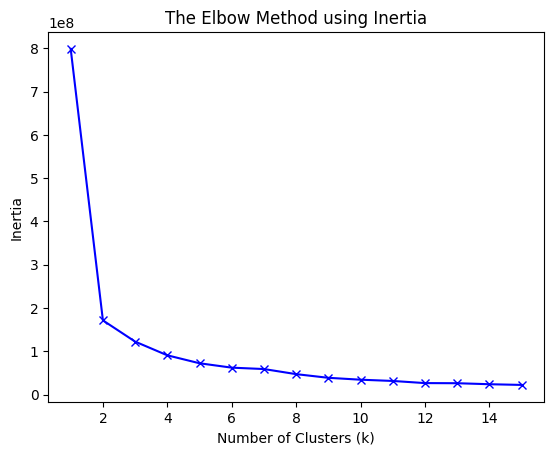

In [11]:
plt.plot(ks, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

Берём 8 кластеров согласно методу локтя

## Кластеризация

In [12]:
km = TimeSeriesKMeans(n_clusters=8, random_state=42, metric='dtw', verbose=True)
y_pred = km.fit_predict(X)

106442193.316 --> 50653008.034 --> 47210497.238 --> 47210497.238 --> 


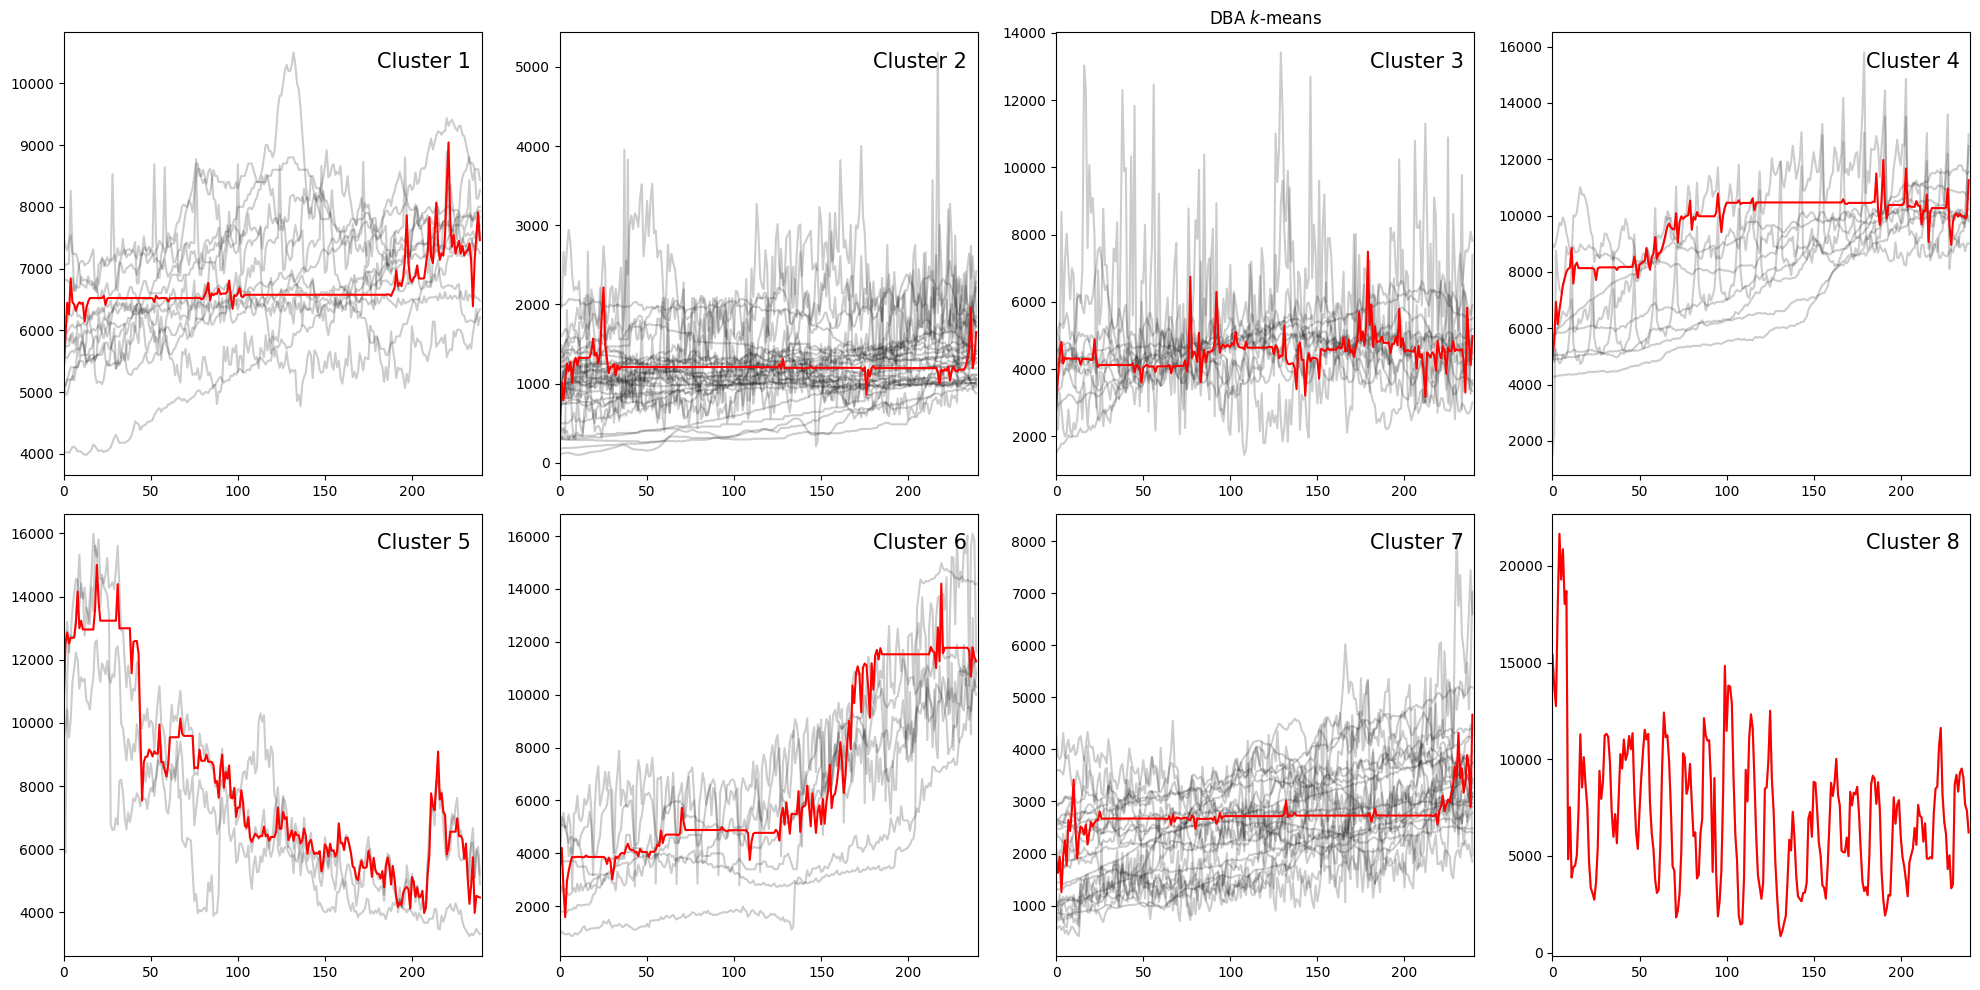

In [13]:
plt.figure(figsize=(20, 10))

for yi in range(8):
    plt.subplot(2, 4, 1 + yi)
    for xx in X[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, X.shape[1])
    plt.text(0.75, 0.92,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes, size=15)
    if yi == 2:
        plt.title("DBA $k$-means")

plt.tight_layout()